In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [2]:
np.random.seed(42)

n_skus = 100
months = pd.date_range('2023-01-01', '2024-12-31', freq='MS')
n_months = len(months)

records = []
sku_types = []

for i in range(n_skus):
    sku_id = f"SKU_{i+1:03d}"
    
    # Assign a true pattern type (we'll verify with ADI/CV2)
    pattern_type = np.random.choice(
        ['smooth', 'erratic', 'intermittent', 'lumpy'],
        p=[0.35, 0.25, 0.20, 0.20]
    )
    
    for month in months:
        if pattern_type == 'smooth':
            # Regular demand, low variability
            demand = max(0, int(np.random.normal(500, 50)))
            
        elif pattern_type == 'erratic':
            # Regular demand, HIGH variability
            demand = max(0, int(np.random.exponential(500)))
            
        elif pattern_type == 'intermittent':
            # Sporadic demand (many zeros), consistent size when it occurs
            if np.random.random() < 0.4:  # 40% chance of demand
                demand = int(np.random.normal(300, 30))
            else:
                demand = 0
                
        elif pattern_type == 'lumpy':
            # Sporadic AND variable
            if np.random.random() < 0.35:  # 35% chance of demand
                demand = max(0, int(np.random.exponential(400)))
            else:
                demand = 0
        
        demand = max(0, demand)
        records.append({
            'Date': month,
            'SKU': sku_id,
            'Demand': demand,
            'True_Pattern': pattern_type
        })
    
    sku_types.append({'SKU': sku_id, 'True_Pattern': pattern_type})

df = pd.DataFrame(records)
sku_info = pd.DataFrame(sku_types)

print(f"Dataset: {len(df)} rows ({n_skus} SKUs x {n_months} months)")
print(f"\nTrue pattern distribution:")
print(sku_info['True_Pattern'].value_counts())
print(f"\nSample data:")
print(df[df['SKU'] == 'SKU_001'].head(6))

Dataset: 2400 rows (100 SKUs x 24 months)

True pattern distribution:
True_Pattern
smooth          33
erratic         30
intermittent    21
lumpy           16
Name: count, dtype: int64

Sample data:
        Date      SKU  Demand True_Pattern
0 2023-01-01  SKU_001    1505      erratic
1 2023-02-01  SKU_001     658      erratic
2 2023-03-01  SKU_001     456      erratic
3 2023-04-01  SKU_001      84      erratic
4 2023-05-01  SKU_001      84      erratic
5 2023-06-01  SKU_001      29      erratic


In [3]:
print("""
=========================================================
THE ADI / CV-SQUARED FRAMEWORK
=========================================================

Two dimensions classify demand patterns:

1. ADI (Average Demand Interval):
   "How often does demand occur?"
   
   ADI = Number of time periods / Number of periods WITH demand
   
   Example A: Demand in all 24 months -> ADI = 24/24 = 1.0
   Example B: Demand in 12 of 24 months -> ADI = 24/12 = 2.0
   Example C: Demand in 6 of 24 months -> ADI = 24/6 = 4.0
   
   ADI = 1.0: demand every period (very regular)
   ADI = 2.0: demand every OTHER period
   ADI = 4.0: demand once every 4 periods (very sporadic)
   
   THRESHOLD: ADI = 1.32
   ADI < 1.32 -> REGULAR demand (occurs frequently)
   ADI >= 1.32 -> INTERMITTENT demand (many zero periods)

2. CV2 (Coefficient of Variation Squared):
   "How variable is demand SIZE when it occurs?"
   
   CV = std(non-zero demands) / mean(non-zero demands)
   CV2 = CV^2
   
   Example A: demands = [500, 520, 490, 510] -> CV = 0.024, CV2 = 0.001
   Example B: demands = [100, 800, 50, 600]  -> CV = 0.700, CV2 = 0.490
   
   Low CV2: demand size is CONSISTENT (same-ish quantity each time)
   High CV2: demand size is VARIABLE (small orders AND huge orders)
   
   THRESHOLD: CV2 = 0.49
   CV2 < 0.49 -> LOW variability (predictable size)
   CV2 >= 0.49 -> HIGH variability (unpredictable size)

CLASSIFICATION MATRIX:
                    CV2 < 0.49          CV2 >= 0.49
                    (Low variability)   (High variability)
ADI < 1.32         SMOOTH              ERRATIC
(Regular timing)   Easy to forecast    Variable qty, regular timing

ADI >= 1.32        INTERMITTENT        LUMPY
(Sporadic timing)  Sporadic but        Sporadic AND variable
                   consistent qty      HARDEST to forecast
""")


THE ADI / CV-SQUARED FRAMEWORK

Two dimensions classify demand patterns:

1. ADI (Average Demand Interval):
   "How often does demand occur?"

   ADI = Number of time periods / Number of periods WITH demand

   Example A: Demand in all 24 months -> ADI = 24/24 = 1.0
   Example B: Demand in 12 of 24 months -> ADI = 24/12 = 2.0
   Example C: Demand in 6 of 24 months -> ADI = 24/6 = 4.0

   ADI = 1.0: demand every period (very regular)
   ADI = 2.0: demand every OTHER period
   ADI = 4.0: demand once every 4 periods (very sporadic)

   THRESHOLD: ADI = 1.32
   ADI < 1.32 -> REGULAR demand (occurs frequently)
   ADI >= 1.32 -> INTERMITTENT demand (many zero periods)

2. CV2 (Coefficient of Variation Squared):
   "How variable is demand SIZE when it occurs?"

   CV = std(non-zero demands) / mean(non-zero demands)
   CV2 = CV^2

   Example A: demands = [500, 520, 490, 510] -> CV = 0.024, CV2 = 0.001
   Example B: demands = [100, 800, 50, 600]  -> CV = 0.700, CV2 = 0.490

   Low CV2: demand 

In [4]:
sku_metrics = []

for sku in df['SKU'].unique():
    sku_data = df[df['SKU'] == sku]['Demand'].values
    
    # ADI calculation
    n_periods = len(sku_data)
    n_nonzero = np.count_nonzero(sku_data)
    
    if n_nonzero == 0:
        adi = float('inf')  # Never has demand
        cv2 = float('inf')
    else:
        adi = n_periods / n_nonzero
        
        # CV2 calculation (on non-zero demands only)
        nonzero_demands = sku_data[sku_data > 0]
        if len(nonzero_demands) > 1:
            cv = nonzero_demands.std() / nonzero_demands.mean()
            cv2 = cv ** 2
        else:
            cv2 = 0
    
    # Classify
    if adi < 1.32 and cv2 < 0.49:
        pattern = 'Smooth'
    elif adi < 1.32 and cv2 >= 0.49:
        pattern = 'Erratic'
    elif adi >= 1.32 and cv2 < 0.49:
        pattern = 'Intermittent'
    else:
        pattern = 'Lumpy'
    
    sku_metrics.append({
        'SKU': sku,
        'ADI': round(adi, 2),
        'CV2': round(cv2, 3),
        'Pattern': pattern,
        'Avg_Demand': round(sku_data.mean(), 1),
        'Nonzero_Periods': n_nonzero,
        'Total_Demand': sku_data.sum()
    })

metrics_df = pd.DataFrame(sku_metrics)

print("SKU Classification Results:")
print(f"\n{metrics_df['Pattern'].value_counts()}")
print(f"\nSample classified SKUs:")
print(metrics_df.head(10).to_string(index=False))

SKU Classification Results:

Pattern
Smooth          35
Erratic         28
Intermittent    24
Lumpy           13
Name: count, dtype: int64

Sample classified SKUs:
    SKU  ADI   CV2      Pattern  Avg_Demand  Nonzero_Periods  Total_Demand
SKU_001 1.00 1.130      Erratic       422.0               24         10127
SKU_002 1.71 0.006 Intermittent       180.7               14          4336
SKU_003 1.00 0.632      Erratic       376.7               24          9040
SKU_004 1.00 0.588      Erratic       553.0               24         13271
SKU_005 1.00 0.008       Smooth       480.3               24         11527
SKU_006 1.00 0.011       Smooth       501.9               24         12045
SKU_007 1.00 0.700      Erratic       478.5               24         11484
SKU_008 1.00 0.009       Smooth       512.1               24         12290
SKU_009 4.00 0.549        Lumpy       110.7                6          2657
SKU_010 3.00 0.349 Intermittent        77.5                8          1861


In [5]:
print("\nMetrics by Pattern:")
summary = metrics_df.groupby('Pattern').agg(
    Count=('SKU', 'count'),
    Avg_ADI=('ADI', 'mean'),
    Avg_CV2=('CV2', 'mean'),
    Avg_Demand=('Avg_Demand', 'mean'),
    Total_Demand=('Total_Demand', 'sum')
).round(2)
summary['Demand_Share'] = (summary['Total_Demand'] / summary['Total_Demand'].sum() * 100).round(1)
print(summary)


Metrics by Pattern:
              Count  Avg_ADI  Avg_CV2  Avg_Demand  Total_Demand  Demand_Share
Pattern                                                                      
Erratic          28     1.00     0.88      498.14        334755          37.9
Intermittent     24     2.55     0.04      131.49         75735           8.6
Lumpy            13     2.81     0.89      173.40         54100           6.1
Smooth           35     1.00     0.03      499.35        419458          47.4


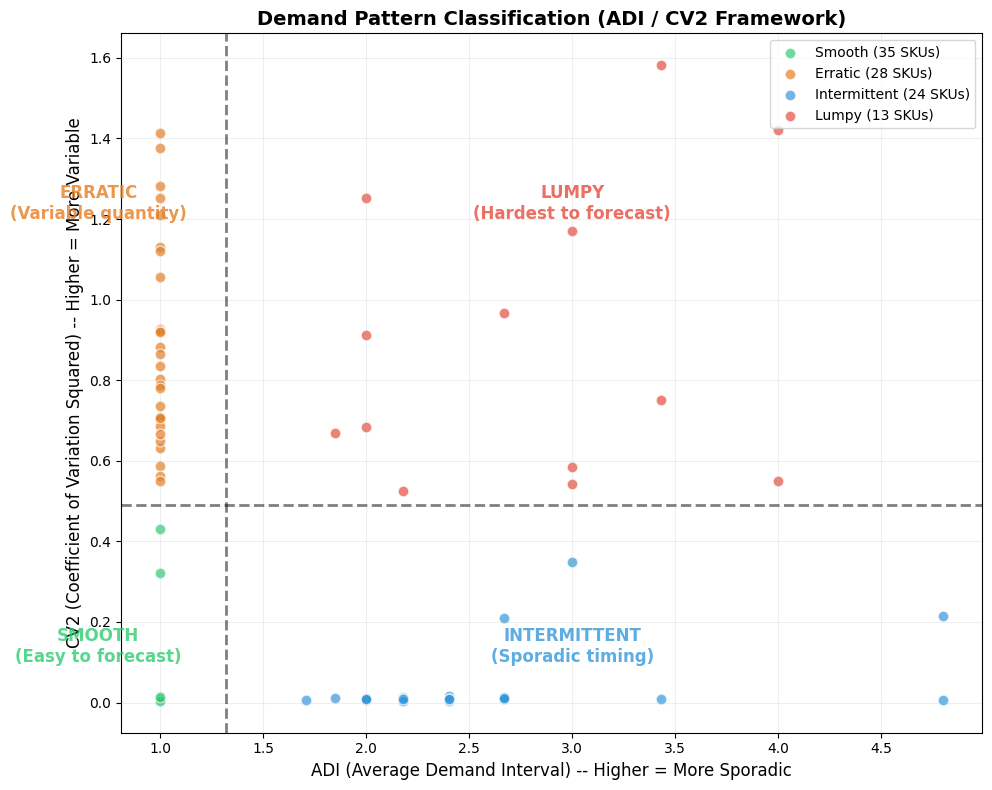

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = {'Smooth': '#2ecc71', 'Erratic': '#e67e22', 'Intermittent': '#3498db', 'Lumpy': '#e74c3c'}
for pattern, color in colors.items():
    mask = metrics_df['Pattern'] == pattern
    ax.scatter(metrics_df[mask]['ADI'], metrics_df[mask]['CV2'],
               c=color, s=60, alpha=0.7, label=f"{pattern} ({mask.sum()} SKUs)", edgecolors='white')

# Draw threshold lines
ax.axvline(1.32, color='black', linewidth=2, linestyle='--', alpha=0.5)
ax.axhline(0.49, color='black', linewidth=2, linestyle='--', alpha=0.5)

# Label quadrants
ax.text(0.7, 0.1, 'SMOOTH\n(Easy to forecast)', ha='center', fontsize=12,
        fontweight='bold', color='#2ecc71', alpha=0.8)
ax.text(0.7, 1.2, 'ERRATIC\n(Variable quantity)', ha='center', fontsize=12,
        fontweight='bold', color='#e67e22', alpha=0.8)
ax.text(3.0, 0.1, 'INTERMITTENT\n(Sporadic timing)', ha='center', fontsize=12,
        fontweight='bold', color='#3498db', alpha=0.8)
ax.text(3.0, 1.2, 'LUMPY\n(Hardest to forecast)', ha='center', fontsize=12,
        fontweight='bold', color='#e74c3c', alpha=0.8)

ax.set_xlabel('ADI (Average Demand Interval) -- Higher = More Sporadic', fontsize=12)
ax.set_ylabel('CV2 (Coefficient of Variation Squared) -- Higher = More Variable', fontsize=12)
ax.set_title('Demand Pattern Classification (ADI / CV2 Framework)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('01_adi_cv2_classification.png', dpi=150, bbox_inches='tight')
plt.show()



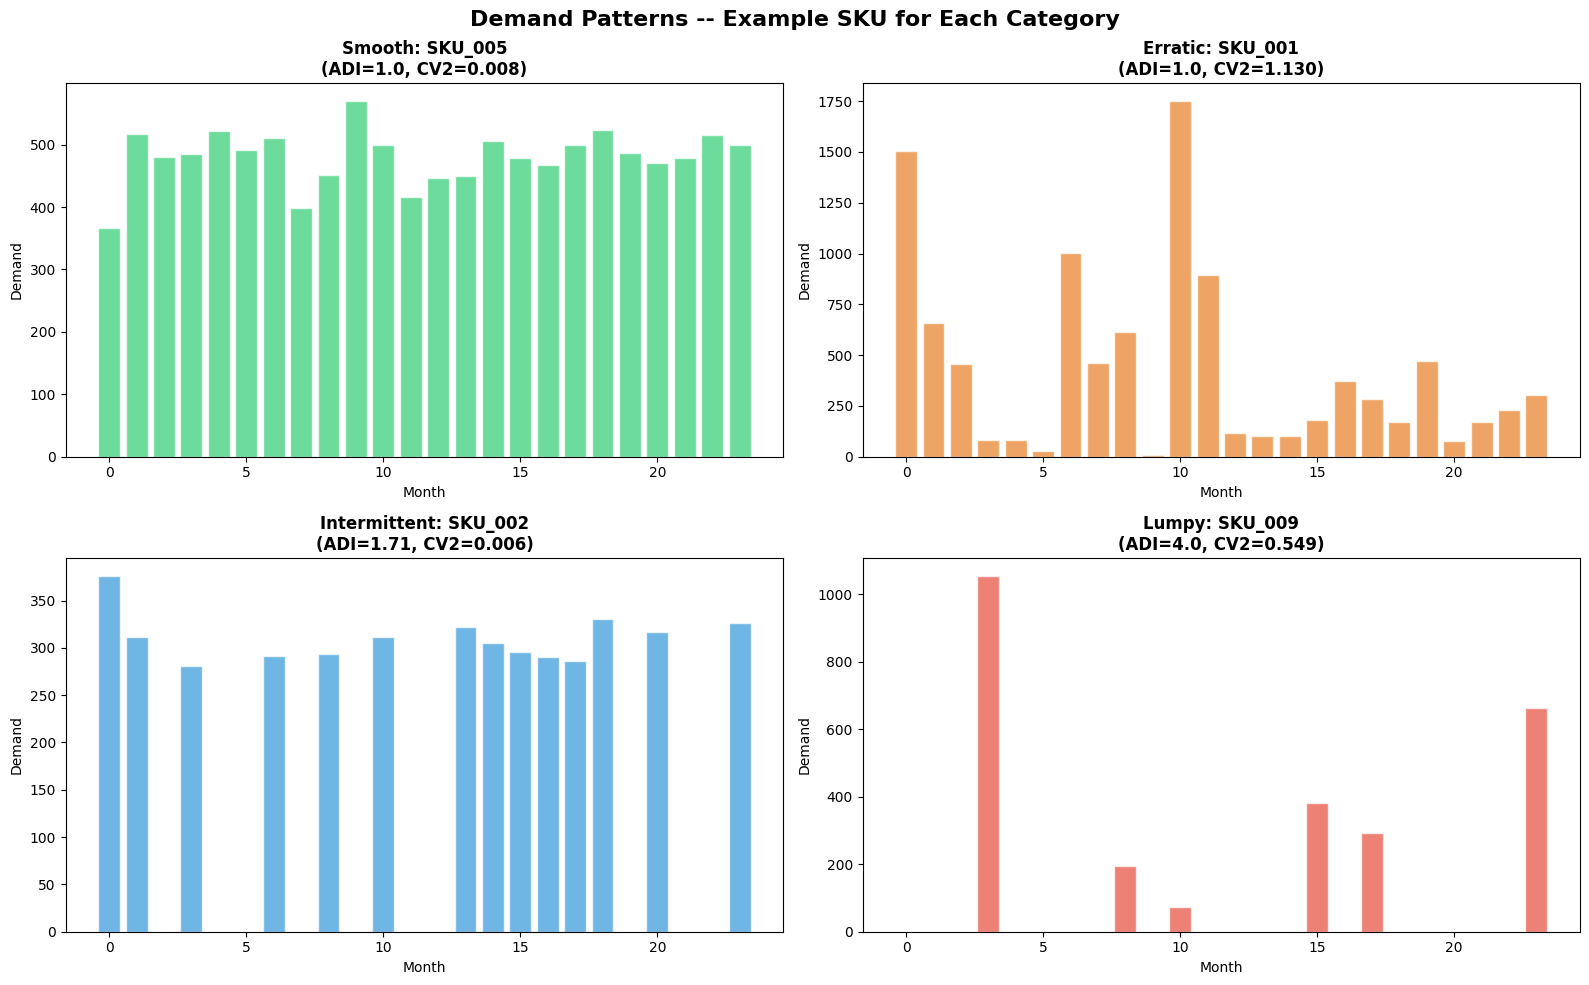

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, pattern in zip(axes.flatten(), ['Smooth', 'Erratic', 'Intermittent', 'Lumpy']):
    sample_sku = metrics_df[metrics_df['Pattern'] == pattern].iloc[0]['SKU']
    sku_data = df[df['SKU'] == sample_sku]
    
    color = colors[pattern]
    ax.bar(range(len(sku_data)), sku_data['Demand'], color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f"{pattern}: {sample_sku}\n(ADI={metrics_df[metrics_df['SKU']==sample_sku]['ADI'].values[0]}, "
                 f"CV2={metrics_df[metrics_df['SKU']==sample_sku]['CV2'].values[0]:.3f})",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Demand')
    ax.set_ylim(bottom=0)

plt.suptitle('Demand Patterns -- Example SKU for Each Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('02_pattern_examples.png', dpi=150, bbox_inches='tight')
plt.show()

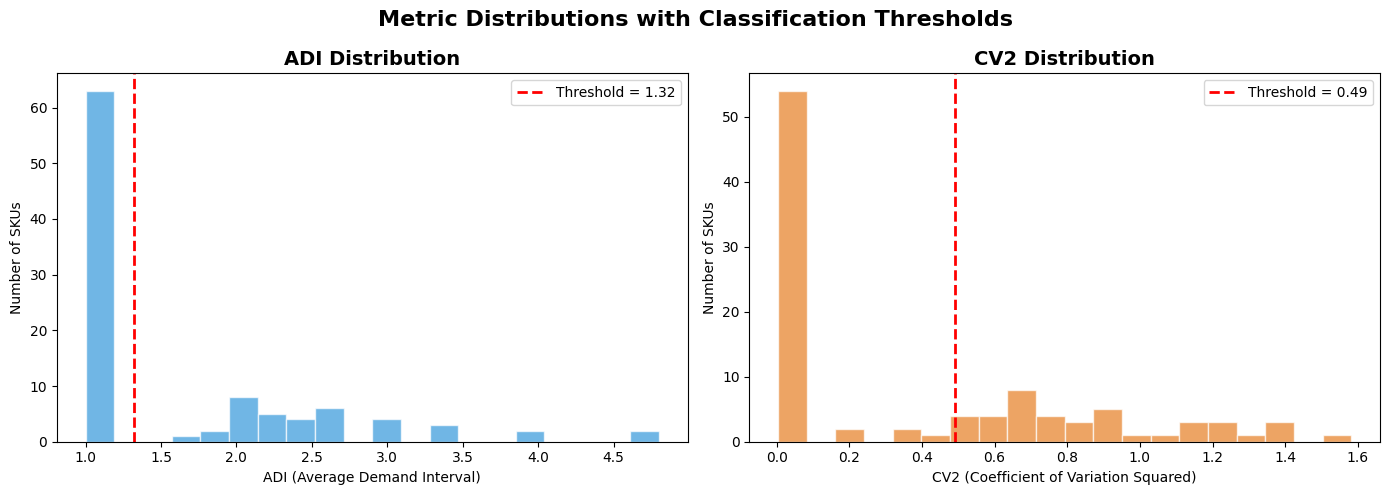

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(metrics_df['ADI'], bins=20, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].axvline(1.32, color='red', linewidth=2, linestyle='--', label='Threshold = 1.32')
axes[0].set_title('ADI Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('ADI (Average Demand Interval)')
axes[0].set_ylabel('Number of SKUs')
axes[0].legend()

axes[1].hist(metrics_df['CV2'].clip(0, 3), bins=20, color='#e67e22', alpha=0.7, edgecolor='white')
axes[1].axvline(0.49, color='red', linewidth=2, linestyle='--', label='Threshold = 0.49')
axes[1].set_title('CV2 Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('CV2 (Coefficient of Variation Squared)')
axes[1].set_ylabel('Number of SKUs')
axes[1].legend()

plt.suptitle('Metric Distributions with Classification Thresholds', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('03_metric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


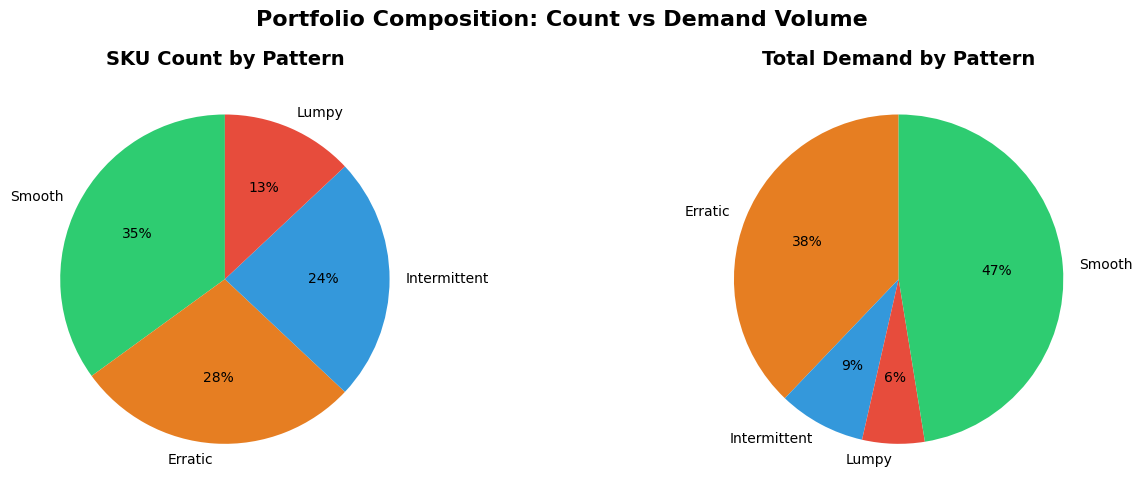

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pattern_counts = metrics_df['Pattern'].value_counts()
pattern_colors = [colors[p] for p in pattern_counts.index]

axes[0].pie(pattern_counts.values, labels=pattern_counts.index, autopct='%1.0f%%',
            colors=pattern_colors, startangle=90)
axes[0].set_title('SKU Count by Pattern', fontsize=14, fontweight='bold')

pattern_demand = metrics_df.groupby('Pattern')['Total_Demand'].sum()
demand_colors = [colors[p] for p in pattern_demand.index]
axes[1].pie(pattern_demand.values, labels=pattern_demand.index, autopct='%1.0f%%',
            colors=demand_colors, startangle=90)
axes[1].set_title('Total Demand by Pattern', fontsize=14, fontweight='bold')

plt.suptitle('Portfolio Composition: Count vs Demand Volume', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('04_portfolio_composition.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print("""
=========================================================
RECOMMENDED FORECASTING METHOD BY PATTERN
=========================================================

PATTERN         METHOD              WHY
-------         ------              ---
SMOOTH          ARIMA / ETS /       Regular patterns. Standard time series
                Prophet             models work well. Lowest error expected.
                                    Target MAPE: 5-15%

ERRATIC         ARIMA with          Regular timing but variable size.
                outlier handling /   Robust methods that dampen extreme values.
                Damped trend ETS     Consider log-transform to stabilize variance.
                                    Target MAPE: 15-25%

INTERMITTENT    Croston's method /  Many zero periods break ARIMA/ETS.
                SBA (Syntetos-      Croston separates demand TIMING from
                Boylan Approx.)     demand SIZE, models each independently.
                                    Target MAPE: 25-40%

LUMPY           Croston's / SBA /   Hardest pattern. Both sporadic AND variable.
                TSB (Teunter-       Consider: aggregate to longer time bucket
                Syntetos-Babai)     (quarterly instead of monthly) to reduce
                                    intermittency, then use standard methods.
                                    Target MAPE: 30-50%+

CROSTON'S METHOD (simplified):
  Instead of forecasting demand directly:
  1. Model INTER-ARRIVAL TIME: how many periods between demands?
  2. Model DEMAND SIZE: when demand occurs, how much?
  3. Forecast = Expected demand size / Expected interval
  
  This handles zeros naturally -- standard ARIMA treats zeros as
  "demand dropped to zero" when actually "no order this period."
""")


RECOMMENDED FORECASTING METHOD BY PATTERN

PATTERN         METHOD              WHY
-------         ------              ---
SMOOTH          ARIMA / ETS /       Regular patterns. Standard time series
                Prophet             models work well. Lowest error expected.
                                    Target MAPE: 5-15%

ERRATIC         ARIMA with          Regular timing but variable size.
                outlier handling /   Robust methods that dampen extreme values.
                Damped trend ETS     Consider log-transform to stabilize variance.
                                    Target MAPE: 15-25%

INTERMITTENT    Croston's method /  Many zero periods break ARIMA/ETS.
                SBA (Syntetos-      Croston separates demand TIMING from
                Boylan Approx.)     demand SIZE, models each independently.
                                    Target MAPE: 25-40%

LUMPY           Croston's / SBA /   Hardest pattern. Both sporadic AND variable.
                TSB 

In [11]:
method_map = {
    'Smooth': 'ARIMA / ETS / Prophet',
    'Erratic': 'Damped ETS / Robust ARIMA',
    'Intermittent': "Croston's / SBA",
    'Lumpy': "Croston's / TSB / Aggregate"
}

target_mape = {
    'Smooth': '5-15%',
    'Erratic': '15-25%',
    'Intermittent': '25-40%',
    'Lumpy': '30-50%+'
}

metrics_df['Recommended_Method'] = metrics_df['Pattern'].map(method_map)
metrics_df['Target_MAPE'] = metrics_df['Pattern'].map(target_mape)

print("\nFull Classification Table (first 15 SKUs):")
print(metrics_df[['SKU', 'ADI', 'CV2', 'Pattern', 'Recommended_Method', 'Target_MAPE']].head(15).to_string(index=False))


Full Classification Table (first 15 SKUs):
    SKU  ADI   CV2      Pattern          Recommended_Method Target_MAPE
SKU_001 1.00 1.130      Erratic   Damped ETS / Robust ARIMA      15-25%
SKU_002 1.71 0.006 Intermittent             Croston's / SBA      25-40%
SKU_003 1.00 0.632      Erratic   Damped ETS / Robust ARIMA      15-25%
SKU_004 1.00 0.588      Erratic   Damped ETS / Robust ARIMA      15-25%
SKU_005 1.00 0.008       Smooth       ARIMA / ETS / Prophet       5-15%
SKU_006 1.00 0.011       Smooth       ARIMA / ETS / Prophet       5-15%
SKU_007 1.00 0.700      Erratic   Damped ETS / Robust ARIMA      15-25%
SKU_008 1.00 0.009       Smooth       ARIMA / ETS / Prophet       5-15%
SKU_009 4.00 0.549        Lumpy Croston's / TSB / Aggregate     30-50%+
SKU_010 3.00 0.349 Intermittent             Croston's / SBA      25-40%
SKU_011 2.18 0.013 Intermittent             Croston's / SBA      25-40%
SKU_012 2.67 0.010 Intermittent             Croston's / SBA      25-40%
SKU_013 1.00 0.010  

In [12]:
print("""
=========================================================
PORTFOLIO FORECASTING STRATEGY
=========================================================

Based on classification results, deploy a DIFFERENTIATED approach:

1. SMOOTH SKUs (largest volume, easiest to forecast):
   - Automate with Prophet/ETS. Monthly review.
   - Invest minimal planner time. Let the model run.
   - Tight safety stock (low uncertainty).

2. ERRATIC SKUs (regular but volatile):
   - Use damped trend models. Flag outliers for review.
   - Moderate planner attention. Investigate spikes.
   - Medium safety stock.

3. INTERMITTENT SKUs (sporadic orders):
   - Switch to Croston's method. Don't use ARIMA/ETS.
   - Review quarterly (less frequent but more strategic).
   - Higher safety stock or make-to-order strategy.

4. LUMPY SKUs (sporadic AND variable -- hardest):
   - Croston's or aggregate to quarterly buckets.
   - Consider: do we NEED a forecast? If order-driven,
     use customer orders directly, not statistical forecast.
   - Highest safety stock or defer to sales intelligence.

THE 80/20 RULE:
   Smooth SKUs are often 30-40% of SKUs but 60-70% of volume.
   Focus forecasting investment on Smooth + Erratic (high volume).
   For Lumpy SKUs, accept higher error and manage with inventory policy.
""")


PORTFOLIO FORECASTING STRATEGY

Based on classification results, deploy a DIFFERENTIATED approach:

1. SMOOTH SKUs (largest volume, easiest to forecast):
   - Automate with Prophet/ETS. Monthly review.
   - Invest minimal planner time. Let the model run.
   - Tight safety stock (low uncertainty).

2. ERRATIC SKUs (regular but volatile):
   - Use damped trend models. Flag outliers for review.
   - Moderate planner attention. Investigate spikes.
   - Medium safety stock.

3. INTERMITTENT SKUs (sporadic orders):
   - Switch to Croston's method. Don't use ARIMA/ETS.
   - Review quarterly (less frequent but more strategic).
   - Higher safety stock or make-to-order strategy.

4. LUMPY SKUs (sporadic AND variable -- hardest):
   - Croston's or aggregate to quarterly buckets.
   - Consider: do we NEED a forecast? If order-driven,
     use customer orders directly, not statistical forecast.
   - Highest safety stock or defer to sales intelligence.

THE 80/20 RULE:
   Smooth SKUs are often 30-

In [13]:
print("\n" + "=" * 70)
print("     PROJECT 13 COMPLETE -- DEMAND PATTERN CLASSIFICATION")
print("=" * 70)
print(f"""
CONCEPTS COVERED:
  -- ADI (Average Demand Interval) = periods / nonzero periods
  -- CV2 (Coefficient of Variation squared) = (std/mean)^2 of nonzero demands
  -- Four demand patterns: Smooth, Erratic, Intermittent, Lumpy
  -- Classification thresholds: ADI = 1.32, CV2 = 0.49
  -- Method-to-pattern mapping (ARIMA for Smooth, Croston for Intermittent)
  -- Portfolio strategy (differentiated approach by pattern)
  -- Croston's method concept (separate timing from size)
  -- Target MAPE by pattern (5-15% smooth to 30-50% lumpy)

CHARTS:
  01 -- ADI vs CV2 scatter (THE classification chart)
  02 -- Example demand pattern for each category
  03 -- ADI and CV2 distributions with threshold lines
  04 -- Portfolio composition (SKU count vs demand volume)

KEY INTERVIEW ANSWERS:
  * "I classify SKUs using the ADI/CV2 framework into smooth, erratic,
     intermittent, and lumpy patterns, then assign the appropriate
     forecasting method to each category."
  * "Smooth demand uses ARIMA/ETS. Intermittent demand uses Croston's
     method which separately models demand timing and size."
  * "Not all SKUs deserve the same forecasting investment. Smooth SKUs
     that drive 70% of volume get automated models. Lumpy SKUs that
     contribute 5% of volume get managed through inventory policy."

BLOCK A COMPLETE!
  Project 1:  Prophet Demand Forecasting
  Project 2:  ARIMA vs Prophet vs ETS
  Project 11: Forecast Accuracy & Bias Dashboard
  Project 12: Hierarchical Demand Forecasting
  Project 13: Demand Pattern Classification
  --> All 5 core demand planning projects DONE!
""")
print("=" * 70)


     PROJECT 13 COMPLETE -- DEMAND PATTERN CLASSIFICATION

CONCEPTS COVERED:
  -- ADI (Average Demand Interval) = periods / nonzero periods
  -- CV2 (Coefficient of Variation squared) = (std/mean)^2 of nonzero demands
  -- Four demand patterns: Smooth, Erratic, Intermittent, Lumpy
  -- Classification thresholds: ADI = 1.32, CV2 = 0.49
  -- Method-to-pattern mapping (ARIMA for Smooth, Croston for Intermittent)
  -- Portfolio strategy (differentiated approach by pattern)
  -- Croston's method concept (separate timing from size)
  -- Target MAPE by pattern (5-15% smooth to 30-50% lumpy)

CHARTS:
  01 -- ADI vs CV2 scatter (THE classification chart)
  02 -- Example demand pattern for each category
  03 -- ADI and CV2 distributions with threshold lines
  04 -- Portfolio composition (SKU count vs demand volume)

KEY INTERVIEW ANSWERS:
  * "I classify SKUs using the ADI/CV2 framework into smooth, erratic,
     intermittent, and lumpy patterns, then assign the appropriate
     forecasting met